<a href="https://colab.research.google.com/github/skang0812/undergrad_ml_assignments/blob/main/05_assignment_glm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

In [ ]:
! git clone https://github.com/ds4e/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 121, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 121 (delta 43), reused 32 (delta 30), pack-reused 65 (from 2)
Receiving objects: 100% (121/121), 1.76 MiB | 8.10 MiB/s, done.
Resolving deltas: 100% (56/56), done.
Download complete
Extracting data files...
Data extracted


**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

Q1 Response

1. We use activation functions like the sigmoid to squash linear predictions into a specific range, like $[0, 1]$, so the model doesn't predict impossible probabilities like $-0.5$ or $1.2$.

2. Binary and categorical cross-entropy are effective because they heavily penalize confident but wrong predictions, forcing the model to align its probabilities with the actual labels.

3. True, it is a Generalized Linear Model because while the output probability is nonlinear, the relationship between the features and the log-odds (the latent variable) is strictly linear.

4. False, it is actually one of the most common tools for classification since we can apply a threshold to the output probability to assign a specific category.

5. No, the coefficient represents the change in the log-odds for a one-unit change in the feature, not a direct 1:1 change in the predicted probability.

6. False, because the model only captures linear relationships in the log-odds, so you still need to manually engineer features to catch complex or non-linear patterns in the data.

7. False, you should choose the model based on the data type. OLS is for continuous numbers, while logistic regression is specifically for categorical outcomes.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


Q2 Response

1.

In [2]:
import pandas as pd
import numpy as np

#load with correct delimiter
df = pd.read_csv('data.csv', sep=';')

cols = ['Debtor', 'Tuition fees up to date', 'Scholarship holder',
        'Age at enrollment', 'Target', 'Curricular units 1st sem (approved)']
df = df[cols]

df = df.dropna()

#create binary target
df['is_dropout'] = (df['Target'] == 'Dropout').astype(int)

2.

Based on the coefficients in your results, students with outstanding debt and those who are older at the time of enrollment are at a higher risk of dropping out, as indicated by the positive coefficients for Debtor and Age at enrollment. Conversely, being a scholarship holder and staying up to date on tuition fees both significantly predict a lower probability of dropping out. Specifically, being up to date on tuition seems to be the most effective factor in reducing dropout risk, as it has the largest negative impact in your model with a coefficient of -2.55.

In [3]:
from sklearn.linear_model import LogisticRegression

X = df[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']]
y = df['is_dropout']

model = LogisticRegression().fit(X, y)

results = pd.DataFrame({'Feature': X.columns, 'Coef': model.coef_[0]})
print(results)

                   Feature      Coef
0                   Debtor  0.530625
1  Tuition fees up to date -2.556542
2       Scholarship holder -1.227442
3        Age at enrollment  0.049925


3.

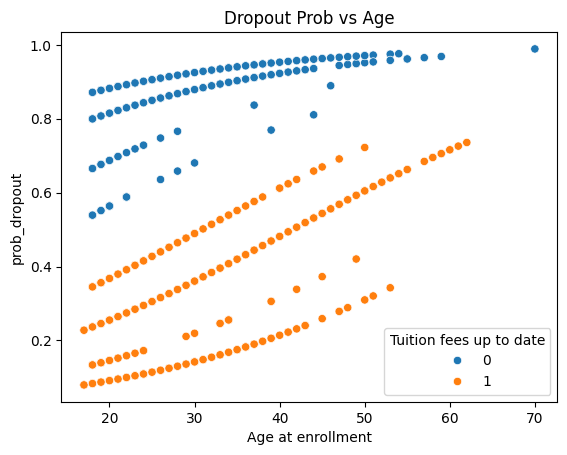

On average, being up to date reduces dropout prob by 61.26%


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

df['prob_dropout'] = model.predict_proba(X)[:, 1]

sns.scatterplot(data=df, x='Age at enrollment', y='prob_dropout', hue='Tuition fees up to date')
plt.title('Dropout Prob vs Age')
plt.show()

#avg change calculation
avg_diff = df[df['Tuition fees up to date'] == 0]['prob_dropout'].mean() - \
           df[df['Tuition fees up to date'] == 1]['prob_dropout'].mean()
print(f"On average, being up to date reduces dropout prob by {avg_diff:.2%}")

4.

In [5]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print("Confusion Matrix:\n", confusion_matrix(y, y_pred))

Accuracy: 0.7619801084990958
Confusion Matrix:
 [[2841  162]
 [ 891  530]]


5.

The histograms show that while both models predict similar distributions, the logistic regression model (prob_dropout) is superior because it naturally constrains all predictions between $0$ and $1$, which is essential for valid probabilities. In contrast, the linear model (lin_prob) produces impossible values, with the x-axis extending past $1.0$ and likely dropping below $0$, proving that a standard linear approach isn't quite right for binary classification. Ultimately, the logistic regression is more reliable here because it ensures every predicted dropout risk stays within a realistic, mathematically sound range.

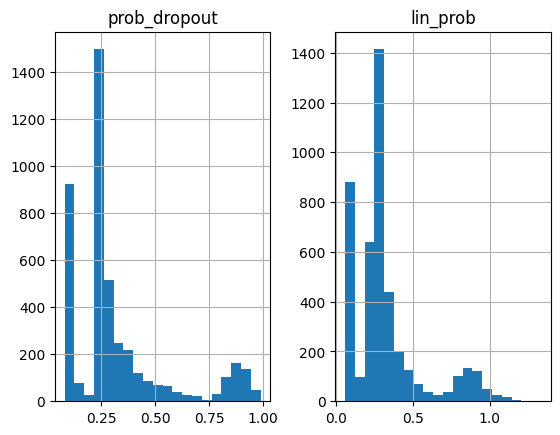

In [6]:
from sklearn.linear_model import LinearRegression

#linear model (OLS)
lin_model = LinearRegression().fit(X, y)
df['lin_prob'] = lin_model.predict(X)

#histogram comparison
df[['prob_dropout', 'lin_prob']].hist(bins=20)
plt.show()

6.

The most at-risk students are older, have debt, and aren't up to date on tuition. You could suggest financial counseling or tuition payment plans to help keep them enrolled.

7.


The confusion matrix shows that while the multinomial model is picking up on "Dropout" and "Graduate" classes, it is completely failing to predict the "Enrolled" class, as evidenced by the middle column of zeros. This happens because the model is defaulting to the more statistically likely categories for its "hard" classifications, effectively ignoring the middle category in its final tally. However, if you check the predicted probabilities, you'll see that every class is actually predicted to some degree, even if those probabilities never cross the threshold to become a final "hard" prediction.

In [7]:
X_multi = df[['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']]
y_multi = df['Target']

multi_model = LogisticRegression(multi_class='multinomial', max_iter=1000).fit(X_multi, y_multi)
multi_pred = multi_model.predict(X_multi)

print("Confusion Matrix:\n", confusion_matrix(y_multi, multi_pred))

Confusion Matrix:
 [[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

Q3 Response

1.

In [8]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

df_cirr = pd.read_csv('cirrhosis.csv')
df_cirr = df_cirr[['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']]

df_cirr = df_cirr.dropna()

df_cirr['is_dead'] = (df_cirr['Status'] == 'D').astype(int)

2.

The coefficients from your model show that higher levels of Bilirubin and more severe cases of Edema (specifically Edema_S and Edema_Y) all predict a higher probability of death, as indicated by their positive values. Because Drug_Placebo has a positive coefficient ($0.038$), it suggests that being in the placebo group slightly increases the risk of death compared to the drug group, though the effect is relatively small. Overall, higher survival rates are predicted by lower bilirubin levels and the absence of edema, while the drug appears to offer a marginal improvement in survival probability.

In [11]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
import numpy as np

df_c = pd.read_csv('cirrhosis.csv')

#filter columns and drop missing values
df_c = df_c[['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']].dropna()

df_c['is_dead'] = (df_c['Status'] == 'D').astype(int)

df_encoded = pd.get_dummies(df_c, columns=['Edema', 'Drug'], drop_first=True)

#define features (X) and target (y)
X = df_encoded.drop(columns=['Status', 'is_dead', 'Stage'])
y = df_encoded['is_dead']

#fit the model
model_c = LogisticRegression().fit(X, y)

res_c = pd.DataFrame({'Feature': X.columns, 'Coef': model_c.coef_[0]})
print(res_c)

        Feature      Coef
0     Bilirubin  0.351424
1       Edema_S  0.450677
2       Edema_Y  1.611049
3  Drug_Placebo -0.231225


3.

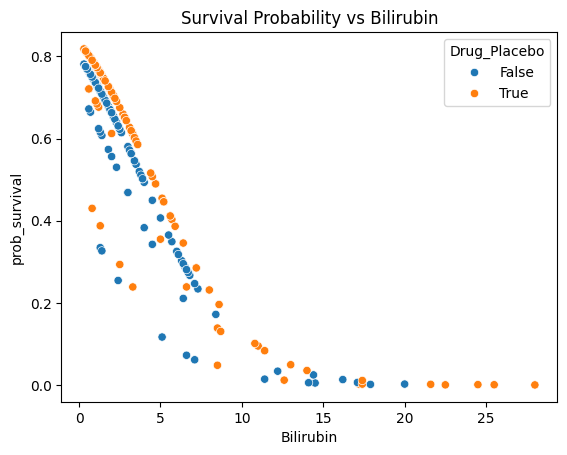

Drug increases survival probability by: -1.88%


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

df_encoded['prob_survival'] = 1 - model_c.predict_proba(X)[:, 1]

sns.scatterplot(data=df_encoded, x='Bilirubin', y='prob_survival', hue='Drug_Placebo')
plt.title('Survival Probability vs Bilirubin')
plt.show()

#average drug impact
avg_survival_drug = df_encoded[df_encoded['Drug_Placebo'] == 0]['prob_survival'].mean()
avg_survival_placebo = df_encoded[df_encoded['Drug_Placebo'] == 1]['prob_survival'].mean()
print(f"Drug increases survival probability by: {avg_survival_drug - avg_survival_placebo:.2%}")

4.

In [13]:
y_pred_c = model_c.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred_c)}")
print("Confusion Matrix:\n", confusion_matrix(y, y_pred_c))

Accuracy: 0.7371794871794872
Confusion Matrix:
 [[171  16]
 [ 66  59]]


5.

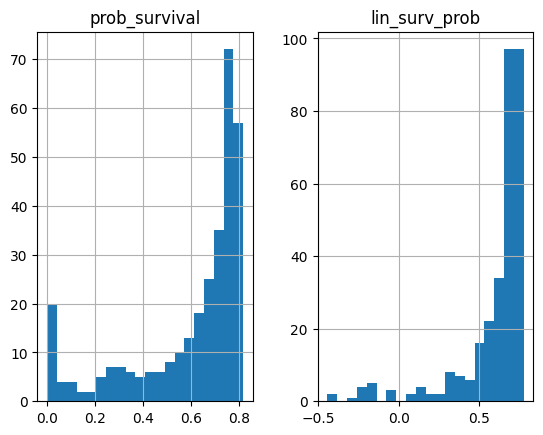

In [14]:
#OLS Model
lin_c = LinearRegression().fit(X, y)
df_encoded['lin_surv_prob'] = 1 - lin_c.predict(X)

#histogram
df_encoded[['prob_survival', 'lin_surv_prob']].hist(bins=20)
plt.show()

6.

The multinomial model is technically working, but it's basically taking the easy way out by predicting Stage 4 for every single patient since that's likely the most common category in the data. Because of that, my hard classification doesn't predict every class but it just sticks to the majority, but the predicted probabilities definitely show a spread across all four stages for every patient. It's not a broken model, it just shows that Bilirubin and Edema alone aren't enough for the model to feel confident enough to pick the earlier stages as the top choice.

In [15]:
#target is Stage (1, 2, 3, or 4)
X_multi = df_encoded[['Bilirubin', 'Edema_S', 'Edema_Y']]
y_multi = df_encoded['Stage']

multi_c = LogisticRegression(multi_class='multinomial', max_iter=1000).fit(X_multi, y_multi)
multi_preds = multi_c.predict(X_multi)

print("Stage Confusion Matrix:\n", confusion_matrix(y_multi, multi_preds))

Stage Confusion Matrix:
 [[  0   0  16   0]
 [  0   0  63   4]
 [  0   0 105  15]
 [  0   0  79  30]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

Q4 Repsonse

1. For the linear model, the derivative with respect to the $k$-th feature is simply the coefficient $b_k$. This means that for a 1-unit change in the feature $x_k$, the prediction $\hat{y}$ changes by exactly $b_k$ units, regardless of what the other variables are.

2. Using the chain rule and the hint provided, the derivative of the logistic prediction $\hat{p}$ with respect to $x_k$ is:$$\frac{\partial \hat{p}}{\partial x_k} = \hat{p}(1 - \hat{p})b_k$$Unlike the linear model, this answer changes as $x$ changes because it depends on the current predicted probability $\hat{p}$. The coefficient $b_k$ (times 0.25) is a good estimate of the effect on the prediction only when $\hat{p} = 0.5$, because that is where the logistic curve is steepest and $\hat{p}(1 - \hat{p})$ reaches its maximum value of $0.25$.

3. When you transform the model into the log-odds form, the relationship becomes linear again. A one-unit change in $x_k$ results in a change of exactly $b_k$ in the log-odds ratio. This is why we like looking at the latent variable because it turns a messy S-curve back into a straightforward linear interpretation.